## fpocket 11 clustering for ensemble docking (with reps)

In [1]:
# kernel fpocket
import sys
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import MDAnalysis as mda
from MDAnalysis.analysis import align
from MDAnalysis.analysis.rms import rmsd, RMSF
from MDAnalysis import Universe

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, silhouette_score

/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


### Load data and select groups
Working with CTD domains of chain A and D.

In [2]:
# Path to full protein runs
path_to_fullprot_r1 = '/biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein/Run1/'
path_to_fullprot_r2 = '/biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein/Run2/'
path_to_fullprot_r3 = '/biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein/Run3/'


grofile_r1= os.path.join(path_to_fullprot_r1, "md_prot.gro")
xtcfile_r1 = os.path.join(path_to_fullprot_r1, "md_prot_cent_ts100.xtc") # full protein 

grofile_r2= os.path.join(path_to_fullprot_r2, "md_prot.gro")
xtcfile_r2 = os.path.join(path_to_fullprot_r2, "md_prot_cent_ts100.xtc") # full protein 

grofile_r3= os.path.join(path_to_fullprot_r3, "md_prot.gro")
xtcfile_r3 = os.path.join(path_to_fullprot_r3, "md_prot_cent_ts100.xtc") # full protein 

# Load universe
u_r1 = mda.Universe(grofile_r1, xtcfile_r1)
u_r2 = mda.Universe(grofile_r2, xtcfile_r2)
u_r3 = mda.Universe(grofile_r3, xtcfile_r3)


In [3]:
# Atom group selection

# CTD selection - chains AD
sel_CTD_A = f'protein and bynum 9054:11750'
CTD_A_r1 = u_r1.select_atoms(sel_CTD_A)
CTD_A_r2 = u_r2.select_atoms(sel_CTD_A)
CTD_A_r3 = u_r3.select_atoms(sel_CTD_A)

sel_CTD_D = f'protein and bynum 44304:47000'
CTD_D_r1 = u_r1.select_atoms(sel_CTD_D)
CTD_D_r2 = u_r2.select_atoms(sel_CTD_D)
CTD_D_r3 = u_r3.select_atoms(sel_CTD_D)

# Whole AD_CTD
sel_AD_CTD = f'protein and bynum 44304:47000 or bynum 9054:11750'
AD_CTD_r1 = u_r1.select_atoms(sel_AD_CTD)
AD_CTD_r2 = u_r2.select_atoms(sel_AD_CTD)
AD_CTD_r3 = u_r3.select_atoms(sel_AD_CTD)

# fpocket11 selection - whole pocket
sel_fp11_A = f'(protein and resid 688 686 684 690 694 761 726 759 753 and bynum 9054:11750)'
# fp11_A_r1 = u_r1.select_atoms(sel_fp11_A)

sel_fp11_D = f'(protein and resid 658 660 659 661 680 and bynum 44304:47000)'
# fp11_D_r1 = u_r1.select_atoms(sel_fp11_D)

sel_fp11_AD = f'{sel_fp11_A} or {sel_fp11_D}'
fp11_AD_r1 = u_r1.select_atoms(sel_fp11_AD)
fp11_AD_r2 = u_r2.select_atoms(sel_fp11_AD)
fp11_AD_r3 = u_r3.select_atoms(sel_fp11_AD)

# Heavy atoms only 
sel_fp11_AD_heavy = f'{sel_fp11_AD} and not name H* and not backbone'
fp11_AD_heavy_r1 = u_r1.select_atoms(sel_fp11_AD_heavy)
fp11_AD_heavy_r2 = u_r2.select_atoms(sel_fp11_AD_heavy)
fp11_AD_heavy_r3 = u_r3.select_atoms(sel_fp11_AD_heavy)


In [4]:
# Atom selection for interface and non-int resids only need single run for ref structure
# Interface resnums

path_to_interface = os.path.join(path_to_fullprot_r1, "clustering/", "chainD_within5A.csv")
interface = pd.read_csv(path_to_interface, index_col=0)
interface.drop_duplicates(inplace=True, subset=['0'])
interface_resnum_str = ' '.join(str(r) for r in interface.iloc[:,0].values)


# Interface selection
sel_int_CTD_A = f'protein and resid {interface_resnum_str} and bynum 9054:11750'
int_CTD_A_r1 = u_r1.select_atoms(sel_int_CTD_A)

sel_int_CTD_D = f'protein and resid {interface_resnum_str} and bynum 44304:47000'
int_CTD_D_r1 = u_r1.select_atoms(sel_int_CTD_D)

# Whole interface from both domains
sel_int_CTD_all = f'protein and resid {interface_resnum_str} and (bynum 44304:47000 or bynum 9054:11750)'
int_CTD_all_r1 = u_r1.select_atoms(sel_int_CTD_all)

# CTD not interface
sel_not_int = f'({sel_AD_CTD}) and not ({sel_int_CTD_A} or {sel_int_CTD_D})'
not_int = u_r1.select_atoms(sel_not_int)


# Not interface backbone only 
sel_not_int_BB = f'{sel_not_int} and name CA C N O'
not_int_BB = u_r1.select_atoms(sel_not_int_BB)

### Align domains - all residues not at interface


In [5]:
# Load real structure PDB
# Frame to align to:
pdb_frame = os.path.join(path_to_fullprot_r1, "6edw_fix.pdb") # full protein 
u_pdb = mda.Universe(pdb_frame)

# Select protein only
pdb_prot = u_pdb.select_atoms('protein')

# ref must be a pdb not gro file - affect the output

/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


In [6]:
# Common reference frame across all reps

ref = Universe(pdb_frame)

# Run1 Align backbone of non-interface CTD residues
align_CTD_AD_r1 = align.AlignTraj(u_r1, ref, select=f'{sel_not_int_BB}', weights="mass", filename='rmsfit_r1.xtc', in_memory=True)
align_CTD_AD_r1.run()

# Save aligned trajectory
with mda.Writer('rep1_aligned.xtc', n_atoms=u_r1.atoms.n_atoms) as W:
    for ts in u_r1.trajectory:
        W.write(u_r1.atoms)
u_r1.atoms.write("rep1_aligned.pdb")

# Run2 Align backbone of non-interface CTD residues
align_CTD_AD_r2 = align.AlignTraj(u_r2, ref, select=f'{sel_not_int_BB}', weights="mass", filename='rmsfit_r2.xtc', in_memory=True)
align_CTD_AD_r2.run()

# Save aligned trajectory
with mda.Writer('rep2_aligned.xtc', n_atoms=u_r2.atoms.n_atoms) as S:
    for ts in u_r2.trajectory:
        S.write(u_r2.atoms)
u_r2.atoms.write("rep2_aligned.pdb")


# Run3 Align backbone of non-interface CTD residues
align_CTD_AD_r3 = align.AlignTraj(u_r3, ref, select=f'{sel_not_int_BB}', weights="mass", filename='rmsfit_r3.xtc', in_memory=True)
align_CTD_AD_r3.run()

# Save aligned trajectory
with mda.Writer('rep3_aligned.xtc', n_atoms=u_r3.atoms.n_atoms) as T:
    for ts in u_r3.trajectory:
        T.write(u_r3.atoms)
u_r3.atoms.write("rep3_aligned.pdb")


/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'altLocs' Using default value of ' '
  warnings.warn("Found no information for attr: '{}'"
/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'icodes' Using default value of ' '
  warnings.warn("Found no information for attr: '{}'"
/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'chainIDs' Using default value of ''
  warnings.warn("Found no information for attr: '{}'"
/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'occupancies' Using default value of '1.0'
  warnings.warn("Found no information for attr: '{}'"
/biggin/b240/ba

### Functions for calculating rmsd - compute per rep

In [7]:
def calc_rmsd(universe, reference, selection):
    """
    Calculate RMSD and plot graph
    """
    # Calculate RMSD
    rmsd = mda.analysis.rms.RMSD(universe, reference, selection, superposition= True)
    rmsd.run()

    # Extract results 
    frames = rmsd.results.rmsd[:,0]
    times = rmsd.results.rmsd[:,1]
    rmsd_out = rmsd.results.rmsd[:,2]

    # Plot graph
    plt.plot(times, rmsd_out)
    plt.xlabel("Time (ps)")
    plt.ylabel("Interface RMSD (Ang)")
    plt.grid(True)
    plt.show()

    return 

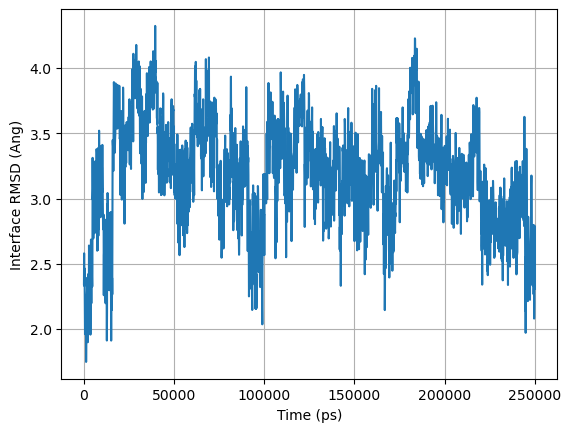

In [8]:
# Run 1 RMSD on heavy atoms in fpocket 11 
calc_rmsd(u_r1, ref, f'{sel_fp11_AD_heavy}')

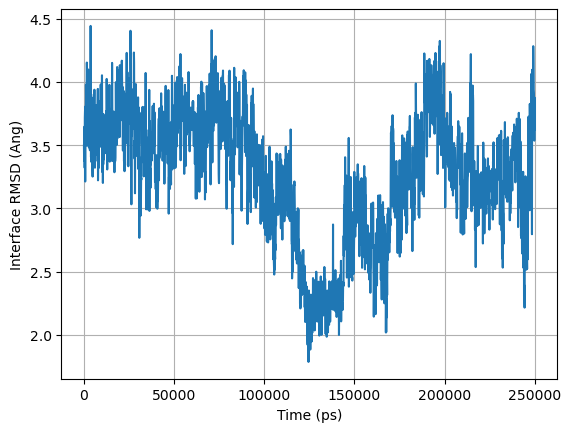

In [ ]:
# Run 2 RMSD on heavy atoms in fpocket 11 
calc_rmsd(u_r2, ref, f'{sel_fp11_AD_heavy}')

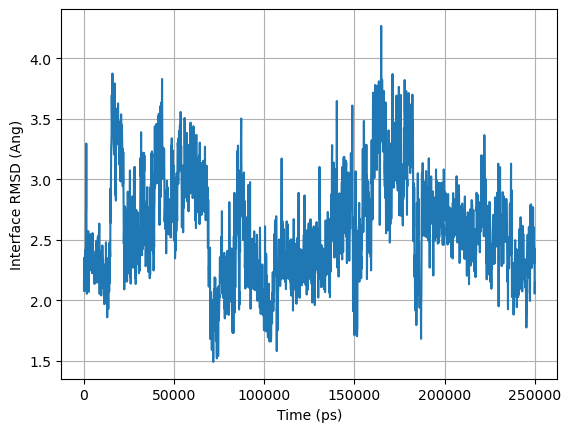

In [21]:
calc_rmsd(u_r3, ref, f'{sel_fp11_AD_heavy}')

### Build coordinate vectors and concat reps 

In [11]:
# Build coordinate matrics and concat reps
# Select heavy atoms only 
sel_fp11_AD_heavy = f'{sel_fp11_AD} and not name H* and not backbone'

# Trajectories and universes
rep_trajs = [("../rep1_aligned.pdb", "../rep1_aligned.xtc"),
              ("../rep2_aligned.pdb", "../rep2_aligned.xtc"),
                ("../rep3_aligned.pdb", "../rep3_aligned.xtc")] # aligned trajectories

coords = []
frame_ids =[]
meta = []

for rep_id, (ref_pdb, ref_traj) in enumerate(rep_trajs):
    uni = Universe(ref_pdb, ref_traj)
    sel_atoms = uni.select_atoms(sel_fp11_AD_heavy)
    print(f'Analysing rep {rep_id}')

    for ts in uni.trajectory[1000:2500]:
        coords.append(sel_atoms.positions.flatten())
        frame_ids.append(uni.trajectory.frame)
        meta.append([rep_id, ts.time])

coords_all = np.vstack(coords)
print (f'Matrix formed and concatenated reps - matrix with shape {np.shape(coords_all)}')

/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "
/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/coordinates/XDR.py:253: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn(


Analysing rep 0
Analysing rep 1
Analysing rep 2
Matrix formed and concatenated reps - matrix with shape (4500, 189)


### PCA on all reps together

In [12]:
# Function to perform PCA 
def do_PCA(coords, n_PCA_components):
    """
    Perform PCA to reduce noise/ dimensionality

    Inputs:
        coords: Coordinates of matrixm, after alignmnet and flattening 
        n_PCA_components: Specify number of PCA components
    
    """

    if coords.shape[0]<2:
        raise SystemExit ("Not enough frames for clustering")
    
    # Calculate PCA
    n_pcas = min(n_PCA_components, coords.shape[0], coords.shape[1])
    pca = PCA(n_components=n_pcas)
    Xpca = pca.fit_transform(coords)
    print ("PCA complete") 

    # Plot
    plt.scatter(Xpca[:,1], Xpca[:,2],marker='.')
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.show()

    return Xpca

PCA complete


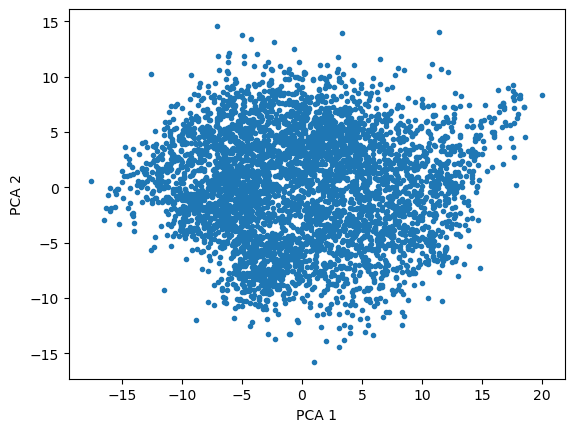

In [13]:
# Do PCA on all reps
Xpca_fp11 = do_PCA(coords_all, 10)

### Cluster (Kmeans) and medoid calculation 

In [1]:
# Clustering functions
# k_clusters=10 
path_to_cluster = os.path.join(path_to_fullprot_r1, "clustering/reps_site11/")

def eval_KMeans(x, k_clusters, r):
    """
    Fit KMeans to data

    Inputs:
        x: Xpca data 
        k_clusters: number of clusters to form/ centroids
        r: random state
    """
    kmeans = KMeans(n_clusters=k_clusters, random_state=r)
    kmeans.fit(x)
    return kmeans.inertia_

# Use elbow method to pick suitable number of clusters
def elbow_KMeans(x, max_k=10, r=42):
    """Perform elbow method to obtain optimal number of clusters"""

    within_cluster_vars = [eval_KMeans(x,k,r) for k in range(1, max_k +1)]
    plt.plot(range(1,11), within_cluster_vars)
    plt.xlabel('K')
    plt.ylabel('Inertia')
    plt.show()

def scatter_kmeans(x, k_clusters, r):
    """Scatter plot the KMeans clusters"""
    
    kmeans = KMeans(n_clusters=k_clusters, init='k-means++', random_state=r )
    y_pred = kmeans.fit_predict(x)

    # Plot
    colours='rbgcmy'
    for c in range(k_clusters):
        plt.scatter(x[y_pred == c, 0], x[y_pred==c, 1], c=colours[c], label='Clusters{}'.format(c), marker='.')
        plt.scatter(kmeans.cluster_centers_[c,0], kmeans.cluster_centers_[c,1], marker='x', c='black')
        plt.xlabel('PC1')
        plt.ylabel('PC2')
    # score = round(silhouette_score(x, kmeans.labels_, metric='euclidean'), 2)
    plt.show()

    # Calculate medoid frames
    medoid_frames = []
    medoid_index = []


    cluster_centroids={}
    medoid_rows=[]
    
    for me in range(k_clusters):
        indexes = np.where(y_pred == me)[0]
        centroid = x[indexes].mean(axis=0)
        cluster_centroids[c] = centroid 

        # medoid in PCA space
        dist = np.linalg.norm(x[indexes] - centroid, axis=1)
        medoid_row = indexes[np.argmin(dist)]
        medoid_rows.append(medoid_row)
    print (f'Medoid rows from concat reps matrix {medoid_rows}')

    # Write medoid structures from correct rep 
    for row in medoid_rows:
        rep_id, frame_id = meta[row]          # make sure frame_id is 0-based for that rep
        top, traj = rep_trajs[rep_id]
        u = mda.Universe(top, traj)
    
        try:
            u.trajectory[int(frame_id/100)]            # move to the medoid frame
        except IndexError:
            u.trajectory[int(frame_id/100)-1]          # if your meta uses 1-based indices

        # Save medoid frames
        output_name = f"medoid_cluster{y_pred[row]}_rep{rep_id}_frame{frame_id}.pdb"
        with mda.Writer(output_name) as W:    # safer writer context
            W.write(u.atoms)
        print("Wrote structure", output_name)


NameError: name 'os' is not defined

In [15]:
# # Find medoids from reps
# medoid_rows=[]
# cluster_members={}
# cluster_centroids={}
# unique_clusters = sorted([c for c in set(y_pred) if c != -1])


# for c in unique_clusters:
#     idxs = np.where(labels == c)[0]
#     cluster_members[c] = idxs
#     centroid = X_pca[idxs].mean(axis=0)
#     cluster_centroids[c] = centroid
#     # medoid in PCA space (closest point to centroid)
#     dists = np.linalg.norm(X_pca[idxs] - centroid, axis=1)
#     medoid_row = idxs[np.argmin(dists)]
#     medoid_rows.append(medoid_row)



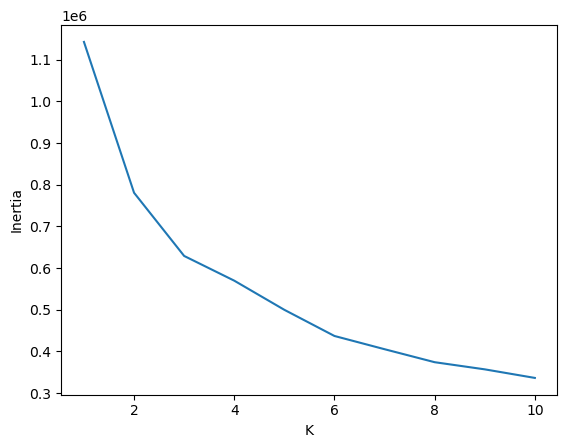

In [16]:
# Evaluate kmeans and plot elbow 
eval_KMeans(Xpca_fp11, 10, 42)
elbow_KMeans(Xpca_fp11)

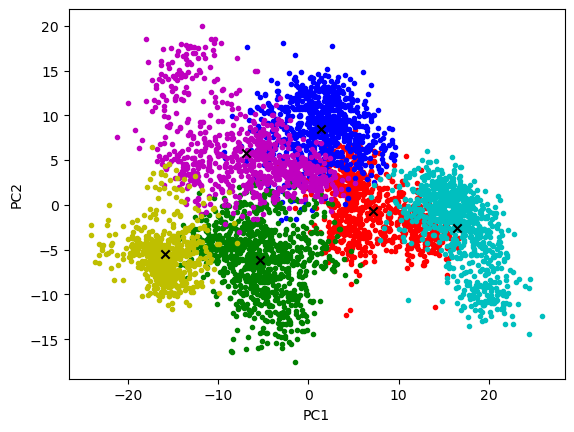

Medoid rows from concat reps matrix [2125, 3465, 360, 4165, 2914, 1063]


/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "
/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'elements' Using default value of ' '
  warnings.warn("Found no information for attr: '{}'"
/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn("Found no information for attr: '{}'"


Wrote structure medoid_cluster0_rep1_frame162500.0.pdb
Wrote structure medoid_cluster1_rep2_frame146500.0.pdb
Wrote structure medoid_cluster2_rep0_frame136000.0.pdb
Wrote structure medoid_cluster3_rep2_frame216500.0.pdb
Wrote structure medoid_cluster4_rep1_frame241400.0.pdb
Wrote structure medoid_cluster5_rep0_frame206300.0.pdb


In [17]:
fp11_ypred = scatter_kmeans(Xpca_fp11, 6, 42)

Much better clustering when including all reps. 6 quite clear clusters and outputs 

### Check if medoid frames are significantly different from eachother
Just recalculate the RMSD between PDB and medoid of the heavy atoms in the pocket of interest <br>
Need to have run `fillin_allchains.sh`

In [19]:
# pdb_frame = os.path.join(path_to_fullprot_r1, "6edw_fix.pdb") # full protein 
# u_pdb = mda.Universe(pdb_frame)

# Select atoms heavy atoms 
pdb_fp11_heavy = u_pdb.select_atoms(sel_fp11_AD_heavy)

# medoids
medoid0_path = os.path.join(path_to_cluster, "medoid_cluster0_fp11.pdb")
medoid0_pdb = mda.Universe(medoid0_path)
medoid0_fp11_heavy = medoid0_pdb.select_atoms(sel_fp11_AD_heavy)

medoid1_path = os.path.join(path_to_cluster, "medoid_cluster1_fp11.pdb")
medoid1_pdb = mda.Universe(medoid1_path)

medoid2_path = os.path.join(path_to_cluster, "medoid_cluster2_fp11.pdb")
medoid2_pdb = mda.Universe(medoid2_path)

medoid3_path = os.path.join(path_to_cluster, "medoid_cluster3_fp11.pdb")
medoid3_pdb = mda.Universe(medoid3_path)

medoid4_path = os.path.join(path_to_cluster, "medoid_cluster4_fp11.pdb")
medoid4_pdb = mda.Universe(medoid4_path)

medoid5_path = os.path.join(path_to_cluster, "medoid_cluster5_fp11.pdb")
medoid5_pdb = mda.Universe(medoid5_path)

In [20]:
# Calculate RMSD on the pocket 
# calc_rmsd(medoid0_pdb, pdb_fp11_heavy, f'{sel_fp11_AD_heavy}')
r = mda.analysis.rms.RMSD(medoid0_pdb, pdb_fp11_heavy, f'{sel_fp11_AD_heavy}', superposition=False, center=False)
r.run()
print (f"RMSD: {r}")


/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/analysis/base.py:542: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time
/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/coordinates/base.py:757: UserWarning: Reader has no dt information, set to 1.0 ps
  return self.ts.time


RMSD: <MDAnalysis.analysis.rms.RMSD object at 0x7851dc3ebf80>
